# Santiago Marin Yepes
1000639952

$$
\Omega_R = \sqrt{\Omega^2-\left(\frac{\Omega}{2}\right)^2}
$$

$$
\Omega_R = \sqrt{\Omega^2-\frac{\Omega^2}{4}}
$$

$$
\Omega_R = \sqrt{\frac{4\Omega^2-\Omega^2}{4}}
$$

$$
\Omega_R = \sqrt{\frac{3\Omega^2}{4}}
$$

$$
\Omega_R = \frac{\sqrt{3}}{2}\Omega
$$

Como

$$
\frac{\Omega}{2\pi} \approx 24.79\ \text{GHz},
$$

entonces

$$
\frac{\Omega_R}{2\pi}
=
\frac{\sqrt{3}}{2}
\frac{\Omega}{2\pi}
$$

$$
\frac{\Omega_R}{2\pi}
=
\frac{\sqrt{3}}{2}
(24.79\ \text{GHz})
$$

$$
\frac{\Omega_R}{2\pi}
\approx 21.47\ \text{GHz}
$$

Por lo tanto, la frecuencia de Rabi en Hz es

$$
f_R = 21.47\times 10^9\ \text{Hz}
$$

$$
\boxed{
f_R \approx 2.147\times 10^{10}\ \text{Hz}
}
$$

Como

$$
\sigma_0 =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix},
\qquad
\sigma_3 =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix},
$$

tenemos

$$
U(t)
=
e^{-iat/\hbar}
\left[
\cos\left(\frac{|c|t}{\hbar}\right)\sigma_0
-
i\sin\left(\frac{|c|t}{\hbar}\right)
\frac{c_z}{|c|}\sigma_3
\right].
$$

Entonces,

$$
U(t)
=
e^{-iat/\hbar}
\begin{pmatrix}
\cos\left(\frac{|c|t}{\hbar}\right)
-
i\frac{c_z}{|c|}
\sin\left(\frac{|c|t}{\hbar}\right)
&
0
\\
0
&
\cos\left(\frac{|c|t}{\hbar}\right)
+
i\frac{c_z}{|c|}
\sin\left(\frac{|c|t}{\hbar}\right)
\end{pmatrix}.
$$

Por lo tanto,

$$
\boxed{
U_{22}(t)
=
e^{-iat/\hbar}
\left[
\cos\left(\frac{|c|t}{\hbar}\right)
+
i\frac{c_z}{|c|}
\sin\left(\frac{|c|t}{\hbar}\right)
\right]
}
$$

Siguiendo el prosedimineto de clase
$$
U_{22}(t)
=
e^{-iat/\hbar}
\left[
\cos(\Omega t)
+
i\frac{\Delta}{\Omega}\sin(\Omega t)
\right]
$$

Como

$$
\Delta=\frac{\Omega_R}{2},
\qquad
\Omega=\sqrt{\Omega_R^2+\Delta^2},
$$

entonces

$$
\Omega
=
\sqrt{\Omega_R^2+\left(\frac{\Omega_R}{2}\right)^2}
=
\frac{\sqrt{5}}{2}\Omega_R.
$$

Por lo tanto,

$$
\frac{\Delta}{\Omega}
=
\frac{\Omega_R/2}{(\sqrt{5}/2)\Omega_R}
=
\frac{1}{\sqrt{5}}.
$$

Así,

$$
\boxed{
U_{22}(t)
=
e^{-iat/\hbar}
\left[
\cos(\Omega t)
+
\frac{i}{\sqrt{5}}\sin(\Omega t)
\right]
}
$$

Frecuencias angulares:
Omega total = 1.558e+11 rad/s
Omega_Rabi  = 1.393e+11 rad/s
Delta       = 6.966e+10 rad/s

Frecuencias en Hz:
Omega / 2pi      = 24.790 GHz
Omega_Rabi / 2pi = 22.173 GHz
Delta / 2pi      = 11.086 GHz


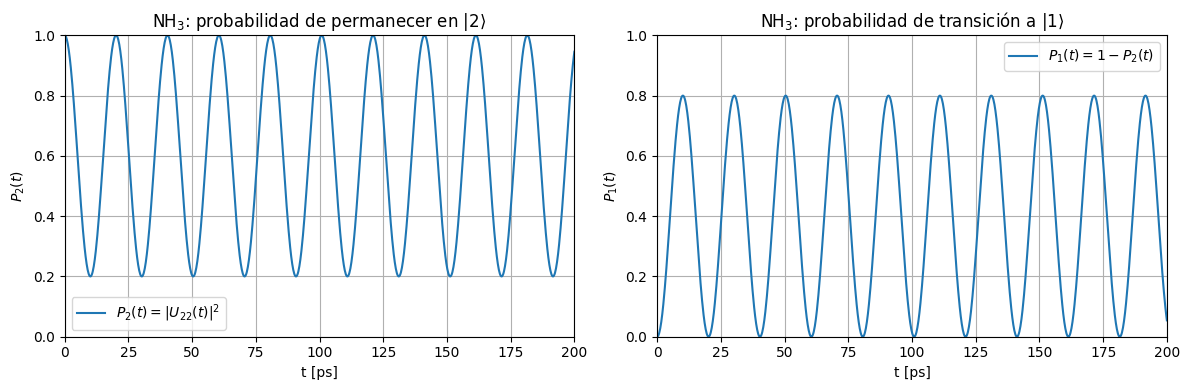

In [3]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Constante de Planck reducida
hbar = 1.0545718e-34  # J*s

# ============================================================
# Funciones del sistema de dos niveles
# ============================================================

# Frecuencia de Rabi
def Omega_Rabi(cx, cy):
    return np.sqrt(cx**2 + cy**2) / hbar

# Detuning
def Delta(cz):
    return np.abs(cz) / hbar

# Frecuencia de Rabi generalizada
def Omega(cx, cy, cz):
    return np.sqrt(Omega_Rabi(cx, cy)**2 + Delta(cz)**2)

# Probabilidad de permanecer en el estado inicial
# Para estado inicial |2>, esta sería P2(t) = |U22(t)|^2
def P_survival(cx, cy, cz, t):
    Om = Omega(cx, cy, cz)
    D = Delta(cz)
    return np.cos(Om*t)**2 + np.sin(Om*t)**2 * (D/Om)**2

# Probabilidad de transición al otro estado
def P_transition(cx, cy, cz, t):
    return 1 - P_survival(cx, cy, cz, t)


# ============================================================
# Caso NH3
# ============================================================

# Frecuencia experimental de inversión del NH3
f_NH3 = 24.79e9  # Hz

# Frecuencia angular total Omega
Omega_NH3 = 2*np.pi*f_NH3  # rad/s

# Condición del problema:
# Delta = Omega_R / 2
#
# Como:
# Omega = sqrt(Omega_R^2 + Delta^2)
#
# Entonces:
# Omega_R = 2 Omega / sqrt(5)
# Delta = Omega / sqrt(5)

Omega_R_NH3 = 2*Omega_NH3 / np.sqrt(5)
Delta_NH3 = Omega_NH3 / np.sqrt(5)

# Queremos construir cx, cy, cz tales que:
#
# Omega_R = sqrt(cx^2 + cy^2)/hbar
# Delta = cz/hbar
#
# Tomamos cx = cy, entonces:
# sqrt(cx^2 + cy^2) = sqrt(2) cx
# cx = hbar Omega_R / sqrt(2)

cx = hbar * Omega_R_NH3 / np.sqrt(2)
cy = hbar * Omega_R_NH3 / np.sqrt(2)
cz = hbar * Delta_NH3

# Verificación
print("Frecuencias angulares:")
print(f"Omega total = {Omega(cx, cy, cz):.3e} rad/s")
print(f"Omega_Rabi  = {Omega_Rabi(cx, cy):.3e} rad/s")
print(f"Delta       = {Delta(cz):.3e} rad/s")
print()

print("Frecuencias en Hz:")
print(f"Omega / 2pi      = {Omega(cx, cy, cz)/(2*np.pi)/1e9:.3f} GHz")
print(f"Omega_Rabi / 2pi = {Omega_Rabi(cx, cy)/(2*np.pi)/1e9:.3f} GHz")
print(f"Delta / 2pi      = {Delta(cz)/(2*np.pi)/1e9:.3f} GHz")


# ============================================================
# Gráfica de las oscilaciones
# ============================================================

# Tiempo en segundos
# Como las frecuencias son del orden de GHz, usamos picosegundos
t = np.linspace(0, 200e-12, 1000)

P2 = P_survival(cx, cy, cz, t)     # Si el estado inicial es |2>
P1 = P_transition(cx, cy, cz, t)   # Probabilidad de pasar a |1>

plt.figure(figsize=(12, 4))

# Probabilidad de permanecer en |2>
plt.subplot(1, 2, 1)
plt.plot(t*1e12, P2, label=r'$P_2(t)=|U_{22}(t)|^2$')
plt.xlabel('t [ps]')
plt.ylabel(r'$P_2(t)$')
plt.xlim(t.min()*1e12, t.max()*1e12)
plt.ylim(0, 1)
plt.title(r'NH$_3$: probabilidad de permanecer en $|2\rangle$')
plt.legend()
plt.grid()

# Probabilidad de transición a |1>
plt.subplot(1, 2, 2)
plt.plot(t*1e12, P1, label=r'$P_1(t)=1-P_2(t)$')
plt.xlabel('t [ps]')
plt.ylabel(r'$P_1(t)$')
plt.xlim(t.min()*1e12, t.max()*1e12)
plt.ylim(0, 1)
plt.title(r'NH$_3$: probabilidad de transición a $|1\rangle$')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

La gráfica describe las oscilaciones de Rabi de la molécula de amoníaco $NH_3$ entre dos estados cuánticos:

$$
|2\rangle \longleftrightarrow |1\rangle .
$$

El sistema empieza en el estado inicial $|2\rangle$, por lo tanto

$$
P_2(0)=1,
\qquad
P_1(0)=0.
$$

La probabilidad de permanecer en el estado inicial $|2\rangle$ es

$$
P_2(t)=|U_{22}(t)|^2.
$$

Usando el elemento de matriz

$$
U_{22}(t)
=
e^{-iat/\hbar}
\left[
\cos(\Omega t)
+
i\frac{\Delta}{\Omega}\sin(\Omega t)
\right],
$$

se tiene

$$
P_2(t)
=
|U_{22}(t)|^2.
$$

Como el factor global de fase no cambia la probabilidad,

$$
\left|e^{-iat/\hbar}\right|^2=1,
$$

entonces

$$
P_2(t)
=
\left|
\cos(\Omega t)
+
i\frac{\Delta}{\Omega}\sin(\Omega t)
\right|^2.
$$

Por lo tanto,

$$
P_2(t)
=
\cos^2(\Omega t)
+
\left(
\frac{\Delta}{\Omega}
\right)^2
\sin^2(\Omega t).
$$

Así, la probabilidad de permanecer en $|2\rangle$ queda

$$
\boxed{
P_2(t)
=
\cos^2(\Omega t)
+
\frac{1}{5}\sin^2(\Omega t)
}
$$

La probabilidad de transición hacia el estado $|1\rangle$ es

$$
P_1(t)=1-P_2(t).
$$

Entonces,

$$
P_1(t)
=
1-
\left[
\cos^2(\Omega t)
+
\frac{1}{5}\sin^2(\Omega t)
\right].
$$

Usando

$$
1-\cos^2(\Omega t)=\sin^2(\Omega t),
$$

obtenemos

$$
P_1(t)
=
\sin^2(\Omega t)
-
\frac{1}{5}\sin^2(\Omega t).
$$

Por lo tanto,

$$
\boxed{
P_1(t)
=
\frac{4}{5}\sin^2(\Omega t)
}
$$

La probabilidad total se conserva:

$$
P_1(t)+P_2(t)=1.
$$

Esto significa que la molécula siempre está distribuida entre los estados $|1\rangle$ y $|2\rangle$.

Como existe detuning,

$$
\Delta \neq 0,
$$

la transición no es completa. El máximo valor de $P_1(t)$ se obtiene cuando

$$
\sin^2(\Omega t)=1.
$$

Entonces,

$$
P_{1,\max}
=
\frac{4}{5}.
$$

Por lo tanto,

$$
\boxed{
P_{1,\max}=0.8
}
$$

Ahora calculemos el valor mínimo de $P_2(t)$.

Tenemos

$$
P_2(t)
=
\cos^2(\Omega t)
+
\frac{1}{5}\sin^2(\Omega t).
$$

El valor mínimo de $P_2(t)$ ocurre cuando

$$
\cos^2(\Omega t)=0,
\qquad
\sin^2(\Omega t)=1.
$$

Reemplazando,

$$
P_{2,\min}
=
0+
\frac{1}{5}(1).
$$

Por lo tanto,

$$
\boxed{
P_{2,\min}
=
\frac{1}{5}
}
$$

o equivalentemente,

$$
\boxed{
P_{2,\min}
=
0.2
}
$$

Esto significa que, debido al detuning, la molécula nunca abandona completamente el estado inicial $|2\rangle$. Como máximo transfiere el $80\%$ de la población hacia $|1\rangle$, y siempre queda al menos un $20\%$ en $|2\rangle$.

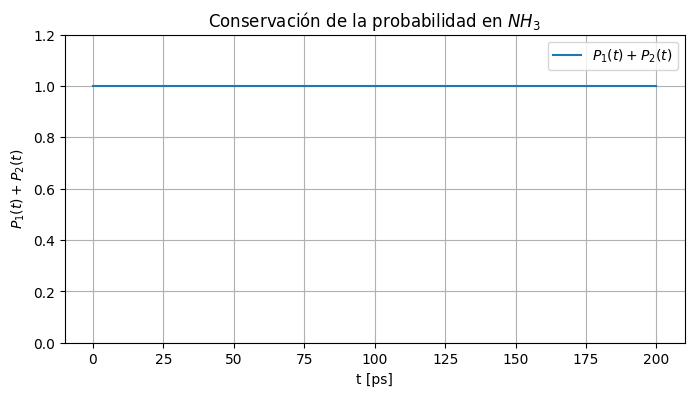

In [5]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Frecuencia experimental del NH3
f_NH3 = 24.79e9  # Hz

# Frecuencia angular total
Omega = 2*np.pi*f_NH3  # rad/s

# Caso del problema:
# Delta = Omega_R / 2
# Omega = sqrt(Omega_R^2 + Delta^2)

Omega_R = 2*Omega/np.sqrt(5)
Delta = Omega/np.sqrt(5)

# Tiempo en segundos
t = np.linspace(0, 200e-12, 1000)

# Probabilidad de permanecer en |2>
P2 = np.cos(Omega*t)**2 + (Delta/Omega)**2 * np.sin(Omega*t)**2

# Probabilidad de transición a |1>
P1 = 1 - P2

# Suma total de probabilidades
P_total = P1 + P2

plt.figure(figsize=(8, 4))

plt.plot(t*1e12, P_total, label=r'$P_1(t)+P_2(t)$')
plt.xlabel('t [ps]')
plt.ylabel(r'$P_1(t)+P_2(t)$')
plt.title(r'Conservación de la probabilidad en $NH_3$')
plt.ylim(0, 1.2)
plt.grid()
plt.legend()

plt.show()

muy bien. este era el primer punto del lab 9

nota 5.0